In [1]:
from google.colab import drive
drive.mount('/content/drive')

BASE = '/content/drive/MyDrive/opinionx'

# Install required libraries
!pip install transformers datasets -q

import pandas as pd
import numpy as np
import torch
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import (accuracy_score, precision_score,
                             recall_score, f1_score,
                             confusion_matrix, classification_report)
import warnings
warnings.filterwarnings('ignore')

# Check if GPU is available
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device: {device}")
print(f"GPU available: {torch.cuda.is_available()}")

Mounted at /content/drive
Device: cuda
GPU available: True


In [2]:
# Use 5k sample — enough for good results, trains in ~15 mins on GPU
df = pd.read_csv(f'{BASE}/data/sample/sample_5k.csv')

print(f"Loaded: {len(df):,} reviews")
print(f"Sentiment distribution:")
print(df['sentiment'].value_counts())
print(f"\nSample review: {df['clean_text'].iloc[0][:100]}")

Loaded: 5,000 reviews
Sentiment distribution:
sentiment
negative    2500
positive    2500
Name: count, dtype: int64

Sample review: i was really excited to get this little speaker right out of the box as soon as it was plugged in to


In [3]:
from sklearn.model_selection import train_test_split
from torch.utils.data import Dataset, DataLoader
from transformers import DistilBertTokenizer

# Split data
X_train, X_test, y_train, y_test = train_test_split(
    df['clean_text'].fillna('').values,
    df['label'].values,
    test_size=0.2,
    random_state=42,
    stratify=df['label'].values
)

print(f"Train: {len(X_train):,}")
print(f"Test:  {len(X_test):,}")

# Load tokenizer
print("\nLoading DistilBERT tokenizer...")
tokenizer = DistilBertTokenizer.from_pretrained('distilbert-base-uncased')
print("Tokenizer loaded")

Train: 4,000
Test:  1,000

Loading DistilBERT tokenizer...


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Tokenizer loaded


In [4]:
class ReviewDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_length=128):
        self.texts = texts
        self.labels = labels
        self.tokenizer = tokenizer
        self.max_length = max_length

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        encoding = self.tokenizer(
            str(self.texts[idx]),
            max_length=self.max_length,
            padding='max_length',
            truncation=True,
            return_tensors='pt'
        )
        return {
            'input_ids': encoding['input_ids'].squeeze(),
            'attention_mask': encoding['attention_mask'].squeeze(),
            'label': torch.tensor(self.labels[idx], dtype=torch.long)
        }

# Create datasets
train_dataset = ReviewDataset(X_train, y_train, tokenizer)
test_dataset  = ReviewDataset(X_test,  y_test,  tokenizer)

# Create dataloaders
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
test_loader  = DataLoader(test_dataset,  batch_size=32, shuffle=False)

print(f"Train batches: {len(train_loader)}")
print(f"Test batches:  {len(test_loader)}")

Train batches: 125
Test batches:  32


In [5]:
from transformers import DistilBertForSequenceClassification
from torch.optim import AdamW
from transformers import get_linear_schedule_with_warmup

print("Loading DistilBERT model...")
model = DistilBertForSequenceClassification.from_pretrained(
    'distilbert-base-uncased',
    num_labels=2
)
model = model.to(device)
print("Model loaded and moved to", device)

# Optimizer and scheduler
EPOCHS = 3
optimizer = AdamW(model.parameters(), lr=2e-5, weight_decay=0.01)
total_steps = len(train_loader) * EPOCHS
scheduler = get_linear_schedule_with_warmup(
    optimizer,
    num_warmup_steps=total_steps // 10,
    num_training_steps=total_steps
)

print(f"Total training steps: {total_steps}")

Loading DistilBERT model...


config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_layer_norm.weight | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
classifier.bias         | MISSING    | 
classifier.weight       | MISSING    | 
pre_classifier.bias     | MISSING    | 
pre_classifier.weight   | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Model loaded and moved to cuda
Total training steps: 375


In [6]:
import time

train_losses = []
train_accuracies = []

print("Starting training...")
print("="*50)

for epoch in range(EPOCHS):
    model.train()
    total_loss = 0
    correct = 0
    total = 0
    start = time.time()

    for batch_idx, batch in enumerate(train_loader):
        input_ids      = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels         = batch['label'].to(device)

        optimizer.zero_grad()

        outputs = model(
            input_ids=input_ids,
            attention_mask=attention_mask,
            labels=labels
        )

        loss = outputs.loss
        logits = outputs.logits

        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        scheduler.step()

        total_loss += loss.item()
        preds = torch.argmax(logits, dim=1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)

        if (batch_idx + 1) % 20 == 0:
            print(f"  Epoch {epoch+1} | Batch {batch_idx+1}/{len(train_loader)} "
                  f"| Loss: {loss.item():.4f}")

    avg_loss = total_loss / len(train_loader)
    avg_acc  = correct / total
    elapsed  = time.time() - start

    train_losses.append(avg_loss)
    train_accuracies.append(avg_acc)

    print(f"\nEpoch {epoch+1}/{EPOCHS} complete")
    print(f"  Avg Loss: {avg_loss:.4f}")
    print(f"  Avg Acc:  {avg_acc:.4f}")
    print(f"  Time:     {elapsed/60:.1f} mins")
    print("="*50)

print("Training complete")

Starting training...
  Epoch 1 | Batch 20/125 | Loss: 0.6808
  Epoch 1 | Batch 40/125 | Loss: 0.4664
  Epoch 1 | Batch 60/125 | Loss: 0.4388
  Epoch 1 | Batch 80/125 | Loss: 0.3059
  Epoch 1 | Batch 100/125 | Loss: 0.1796
  Epoch 1 | Batch 120/125 | Loss: 0.4760

Epoch 1/3 complete
  Avg Loss: 0.4097
  Avg Acc:  0.8153
  Time:     0.7 mins
  Epoch 2 | Batch 20/125 | Loss: 0.1786
  Epoch 2 | Batch 40/125 | Loss: 0.0839
  Epoch 2 | Batch 60/125 | Loss: 0.0356
  Epoch 2 | Batch 80/125 | Loss: 0.3498
  Epoch 2 | Batch 100/125 | Loss: 0.3624
  Epoch 2 | Batch 120/125 | Loss: 0.1453

Epoch 2/3 complete
  Avg Loss: 0.1764
  Avg Acc:  0.9397
  Time:     0.8 mins
  Epoch 3 | Batch 20/125 | Loss: 0.0233
  Epoch 3 | Batch 40/125 | Loss: 0.2129
  Epoch 3 | Batch 60/125 | Loss: 0.0690
  Epoch 3 | Batch 80/125 | Loss: 0.0911
  Epoch 3 | Batch 100/125 | Loss: 0.0175
  Epoch 3 | Batch 120/125 | Loss: 0.2247

Epoch 3/3 complete
  Avg Loss: 0.1112
  Avg Acc:  0.9660
  Time:     0.7 mins
Training complet

In [7]:
model.eval()
all_preds = []
all_labels = []

print("Evaluating on test set...")

with torch.no_grad():
    for batch in test_loader:
        input_ids      = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels         = batch['label'].to(device)

        outputs = model(
            input_ids=input_ids,
            attention_mask=attention_mask
        )

        preds = torch.argmax(outputs.logits, dim=1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

y_pred = np.array(all_preds)
y_true = np.array(all_labels)

print("\n" + "="*50)
print("DISTILBERT RESULTS")
print("="*50)
print(f"Accuracy:  {accuracy_score(y_true, y_pred):.4f}")
print(f"Precision: {precision_score(y_true, y_pred):.4f}")
print(f"Recall:    {recall_score(y_true, y_pred):.4f}")
print(f"F1 Score:  {f1_score(y_true, y_pred):.4f}")
print("\nClassification Report:")
print(classification_report(y_true, y_pred,
                             target_names=['Negative', 'Positive']))

Evaluating on test set...

DISTILBERT RESULTS
Accuracy:  0.9230
Precision: 0.9256
Recall:    0.9200
F1 Score:  0.9228

Classification Report:
              precision    recall  f1-score   support

    Negative       0.92      0.93      0.92       500
    Positive       0.93      0.92      0.92       500

    accuracy                           0.92      1000
   macro avg       0.92      0.92      0.92      1000
weighted avg       0.92      0.92      0.92      1000



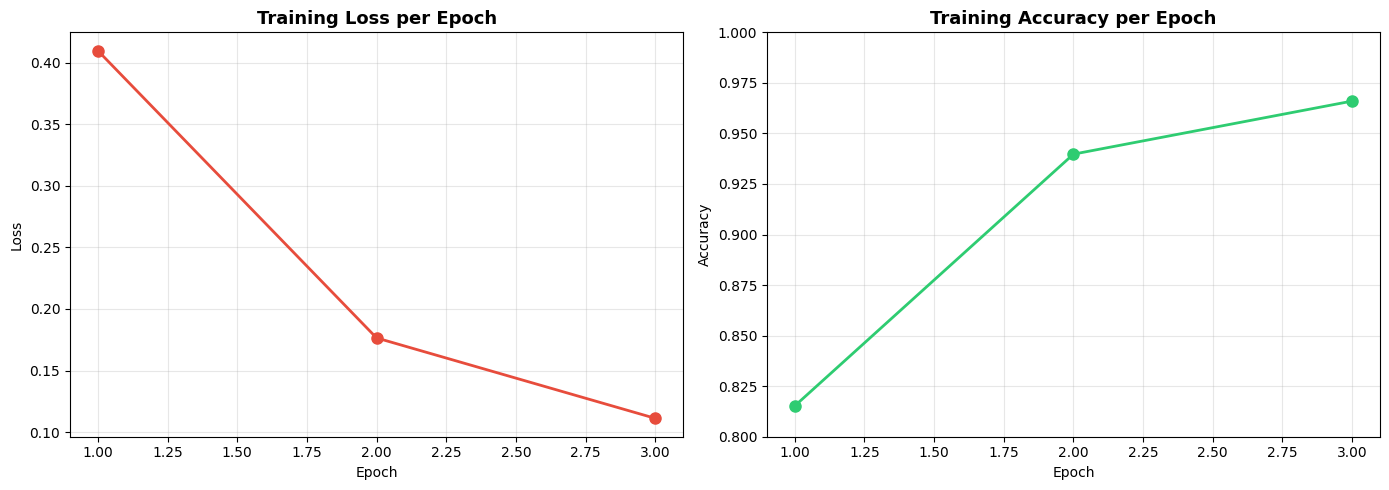

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(range(1, EPOCHS+1), train_losses,
             marker='o', color='#e74c3c', linewidth=2, markersize=8)
axes[0].set_title('Training Loss per Epoch',
                  fontsize=13, fontweight='bold')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].grid(alpha=0.3)

axes[1].plot(range(1, EPOCHS+1), train_accuracies,
             marker='o', color='#2ecc71', linewidth=2, markersize=8)
axes[1].set_title('Training Accuracy per Epoch',
                  fontsize=13, fontweight='bold')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].set_ylim(0.8, 1.0)
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig(f'{BASE}/outputs/plots/08_distilbert_training.png',
            dpi=150, bbox_inches='tight')
plt.show()

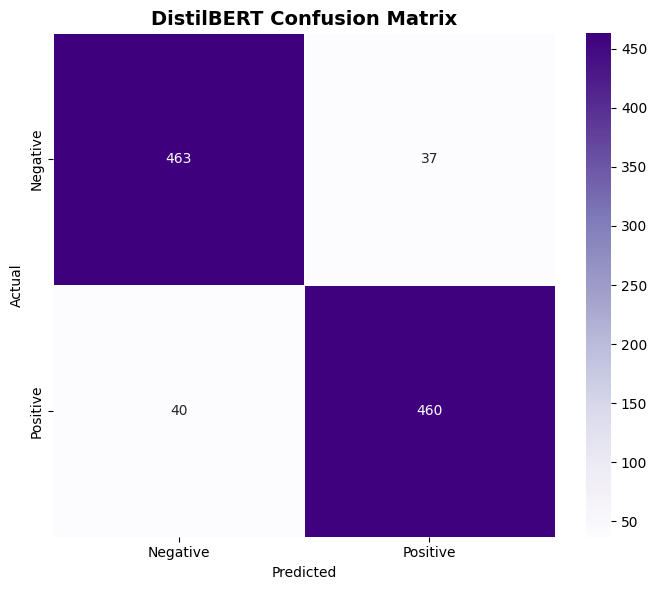

In [9]:
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(7, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Purples',
            xticklabels=['Negative', 'Positive'],
            yticklabels=['Negative', 'Positive'],
            linewidths=0.5)
plt.title('DistilBERT Confusion Matrix', fontsize=14, fontweight='bold')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.savefig(f'{BASE}/outputs/plots/09_distilbert_confusion.png',
            dpi=150, bbox_inches='tight')
plt.show()

In [10]:
# Load baseline results
baseline_results = pd.read_csv(f'{BASE}/outputs/results.csv')

# Add DistilBERT
distilbert_result = pd.DataFrame([{
    'Model': 'DistilBERT',
    'Accuracy':  round(accuracy_score(y_true, y_pred), 4),
    'Precision': round(precision_score(y_true, y_pred), 4),
    'Recall':    round(recall_score(y_true, y_pred), 4),
    'F1':        round(f1_score(y_true, y_pred), 4)
}])

all_results = pd.concat([baseline_results, distilbert_result])
all_results = all_results.sort_values('F1', ascending=False).reset_index(drop=True)

print("="*60)
print("FINAL MODEL COMPARISON — ALL MODELS")
print("="*60)
print(all_results.to_string(index=False))
print("="*60)

# Save updated results
all_results.to_csv(f'{BASE}/outputs/results.csv', index=False)
print("\nResults saved")

FINAL MODEL COMPARISON — ALL MODELS
              Model  Accuracy  Precision  Recall     F1
         Linear SVM    0.9584     0.9662  0.9500 0.9580
Logistic Regression    0.9411     0.9485  0.9328 0.9406
        Naive Bayes    0.9362     0.9364  0.9360 0.9362
         DistilBERT    0.9230     0.9256  0.9200 0.9228

Results saved


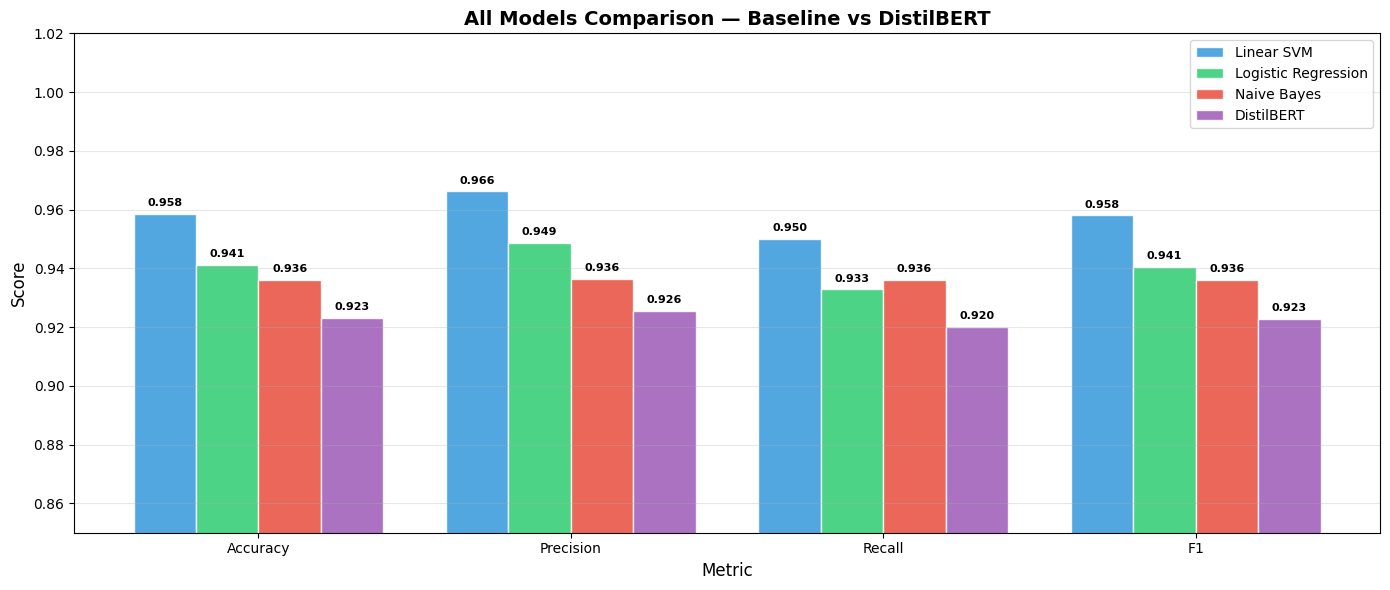

In [11]:
metrics = ['Accuracy', 'Precision', 'Recall', 'F1']
x = np.arange(len(metrics))
width = 0.2
colors = ['#3498db', '#2ecc71', '#e74c3c', '#9b59b6']

fig, ax = plt.subplots(figsize=(14, 6))

for i, (_, row) in enumerate(all_results.iterrows()):
    vals = [row[m] for m in metrics]
    bars = ax.bar(x + i*width, vals, width,
                  label=row['Model'], color=colors[i],
                  edgecolor='white', alpha=0.85)
    for bar, val in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2,
                bar.get_height() + 0.002,
                f'{val:.3f}', ha='center', va='bottom',
                fontsize=8, fontweight='bold')

ax.set_xlabel('Metric', fontsize=12)
ax.set_ylabel('Score', fontsize=12)
ax.set_title('All Models Comparison — Baseline vs DistilBERT',
             fontsize=14, fontweight='bold')
ax.set_xticks(x + width * 1.5)
ax.set_xticklabels(metrics)
ax.set_ylim(0.85, 1.02)
ax.legend(fontsize=10)
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig(f'{BASE}/outputs/plots/10_final_comparison.png',
            dpi=150, bbox_inches='tight')
plt.show()

In [12]:
import os
model_save_path = f'{BASE}/outputs/models/distilbert_sentiment'
os.makedirs(model_save_path, exist_ok=True)

model.save_pretrained(model_save_path)
tokenizer.save_pretrained(model_save_path)

print(f"DistilBERT saved to: {model_save_path}")

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

DistilBERT saved to: /content/drive/MyDrive/opinionx/outputs/models/distilbert_sentiment
